# Imports & API Client Init

In [1]:
import json
import logging
import pandas as pd
from polymarket_client import PolymarketClient
from feature_engineer import engineer_features
from hmm import train_regime_model_walkforward

logging.basicConfig(level=logging.WARNING)
client = PolymarketClient()

# Feature Engineering

In [2]:
market_id = "1163699"
market = client.get_market_details(market_id)
token_ids = json.loads(market.get("clobTokenIds", "[]"))
target_token_id = token_ids[0]

raw_response = client.get_token_history(
    token_id=target_token_id, fidelity=240, total_days=90, chunk_days=7
)
df = engineer_features(raw_response["history"])
print(f"Rows: {len(df)}")
df.head()

Rows: 524


,price,log_return,volatility_24h,fwd_log_return
timestamp,,,,
2026-05-08 16:00:06,0.725,0.056753,0.038807,-0.064079
2026-05-08 20:00:08,0.680,-0.064079,0.047921,0.084557
2026-05-09 00:00:25,0.740,0.084557,0.057029,0.000000
2026-05-09 04:00:06,0.740,0.000000,0.055789,0.006734
2026-05-09 08:00:11,0.745,0.006734,0.055536,-0.013514


# Model Training

In [3]:
# Model Training (Walk-Forward / Causal)
n_components = 4

model, states = train_regime_model_walkforward(
    df,
    n_components=n_components,
    min_train_size=150,  # ~3 weeks of hourly bars before any state is trusted
    refit_every=12,  # refit daily as new data comes in
)
df["state"] = states

# Drop the warm-up period where no state could be assigned
warmup_mask = df["state"] == -1
print(f"Dropping {warmup_mask.sum()} warm-up bars (state = -1)")
df = df[~warmup_mask].copy()

print(f"Remaining rows: {len(df)}")
df.head()

Dropping 150 warm-up bars (state = -1)
Remaining rows: 374


,price,log_return,volatility_24h,fwd_log_return,state
timestamp,,,,,
2026-06-02 20:00:19,0.555,0.018182,0.053525,0.000000,0
2026-06-03 00:00:10,0.555,0.000000,0.053498,0.052644,0
2026-06-03 04:00:05,0.585,0.052644,0.057097,0.082013,0
2026-06-03 08:00:07,0.635,0.082013,0.029201,-0.032003,0
2026-06-03 12:00:09,0.615,-0.032003,0.041975,0.000000,0


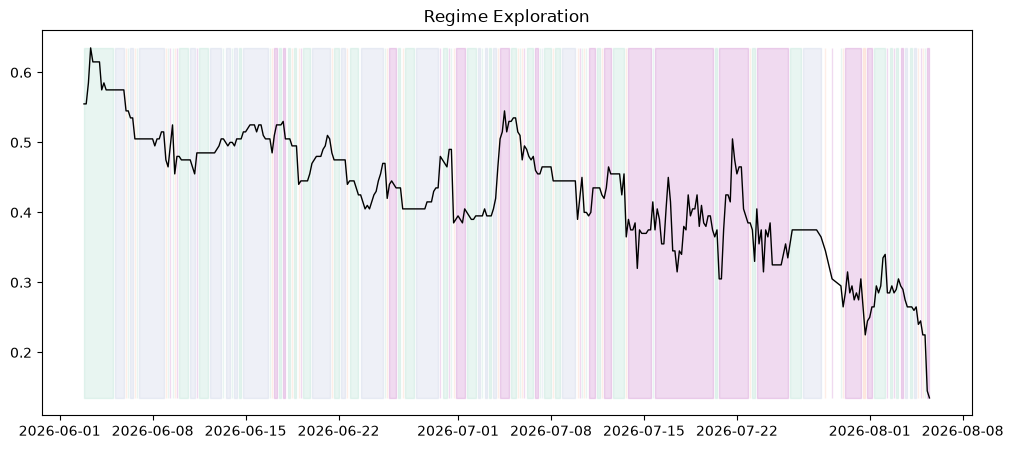

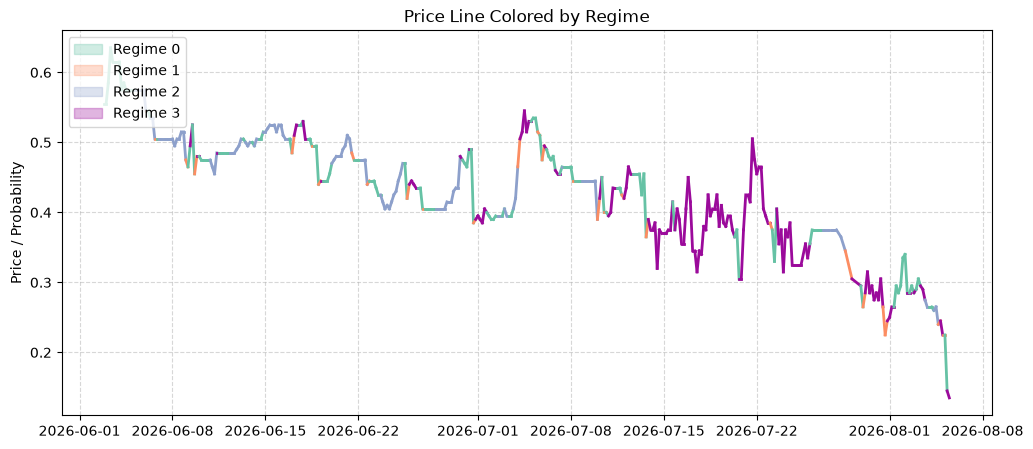

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

colors = ["#66c2a5", "#fc8d62", "#8da0cb", "#9b0a9b", "#c9100a", "#e6ff06", "#1405e2"]

fig1, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(df.index, df["price"], color="black", lw=1)
for i in range(n_components):
    mask = df["state"] == i
    ax1.fill_between(
        df.index,
        df["price"].min(),
        df["price"].max(),
        where=mask,
        color=colors[i],
        alpha=0.15,
        step="post",
    )
ax1.set_title("Regime Exploration")
plt.show()

fig2, ax2 = plt.subplots(figsize=(12, 5))
for i in range(len(df) - 1):
        s = df["state"].iloc[i]
        ax2.plot(
            df.index[i : i + 2],
            df["price"].iloc[i : i + 2],
            color=colors[s],
            lw=2,
        )
ax2.set_ylabel("Price / Probability")
ax2.set_title("Price Line Colored by Regime")
ax2.grid(True, linestyle="--", alpha=0.5)

legend_handles = [
        Patch(color=colors[i], alpha=0.3, label=f"Regime {i}")
        for i in range(n_components)
    ]

ax2.legend(handles=legend_handles, loc="upper left")
plt.show()

# Summary

In [5]:
print("REGIME SUMMARY")
summary = (
    df.groupby("state")
    .agg(
        count=("price", "size"),
        pct_of_time=("price", lambda x: len(x) / len(df) * 100),
        avg_price=("price", "mean"),
        avg_return=("log_return", "mean"),
        avg_volatility=("volatility_24h", "mean"),
        std_return=("log_return", "std"),
    )
    .round(4)
)
display(summary)

print("TRANSITION MATRIX")
trans = pd.DataFrame(
    model.transmat_,
    index=[f"From {i}" for i in range(n_components)],
    columns=[f"To {i}" for i in range(n_components)],
).round(3)
display(trans)

print("REGIME DURATIONS")
state_changes = df["state"] != df["state"].shift(1)
regime_lengths = state_changes.cumsum().value_counts().sort_index()
print(f"Average regime duration: {regime_lengths.mean():.1f} hours")
print(f"Longest regime stretch:  {regime_lengths.max()} hours")
print(f"Shortest regime stretch: {regime_lengths.min()} hours")

print("CURRENT STATE")
current_state = df["state"].iloc[-1]
print(f"Current regime:     {current_state}")
print(f"Current price:      {df['price'].iloc[-1]:.4f}")
print(f"Current volatility: {df['volatility_24h'].iloc[-1]:.4f}")

REGIME SUMMARY


,count,pct_of_time,avg_price,avg_return,avg_volatility,std_return
state,,,,,,
0,122,32.6203,0.4486,0.0033,0.0385,0.0298
1,27,7.2193,0.4061,-0.0834,0.0488,0.0685
2,104,27.8075,0.4598,0.0023,0.0112,0.0156
3,121,32.3529,0.3864,0.0017,0.0848,0.0890


TRANSITION MATRIX


,To 0,To 1,To 2,To 3
From 0,0.604,0.089,0.00,0.307
From 1,0.045,0.923,0.00,0.031
From 2,0.110,0.000,0.89,0.000
From 3,0.157,0.000,0.17,0.673


REGIME DURATIONS
Average regime duration: 3.1 hours
Longest regime stretch:  27 hours
Shortest regime stretch: 1 hours
CURRENT STATE
Current regime:     3
Current price:      0.1350
Current volatility: 0.1672


RAW FORWARD RETURN STATS (What the model is actually trying to predict):
count    374.00000
mean      -0.00341
std        0.06146
min       -0.43937
25%       -0.01303
50%        0.00000
75%        0.01270
max        0.20661
Name: fwd_log_return, dtype: float64

Note: If the mean is ~0.000x, then an edge of 0.01 (1%) is impossible to hit.

Running diagnostic backtest (thresholds disabled to force trades)...


=== DIAGNOSTIC RESULTS ===
Position changes: 86
Total PnL ($1 notional): $-1.1050
Bar win rate:     15.0%
Sharpe (per bar): -0.147


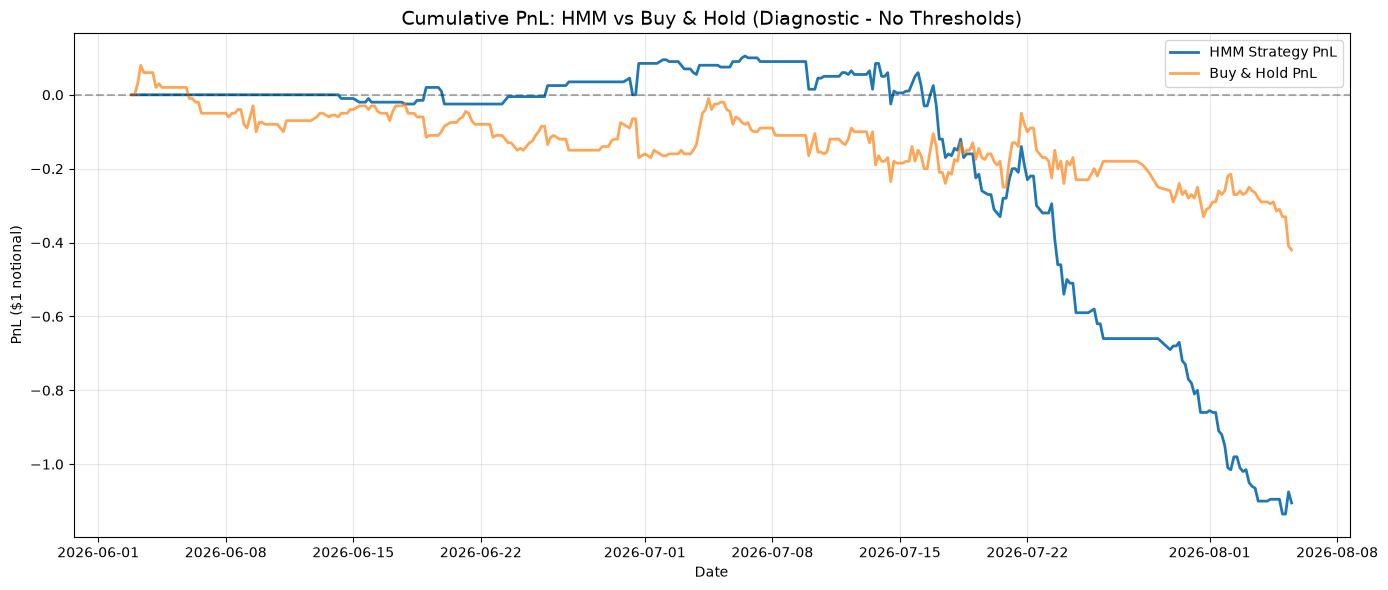

In [6]:
from backtest_engine import SimpleBacktester
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# DIAGNOSTIC 1: Raw Data Check
# =============================================================================
print("RAW FORWARD RETURN STATS (What the model is actually trying to predict):")
print(df["fwd_log_return"].describe().round(5))
print(
    "\nNote: If the mean is ~0.000x, then an edge of 0.01 (1%) is impossible to hit.\n"
)

# =============================================================================
# DIAGNOSTIC 2: Backtest with Disabled Thresholds
# =============================================================================
# Lowered sample requirement and disabled thresholds to see pure directional power
min_samples_per_state = 30
mapping_refresh_every = 12
min_edge = 0.0  # DISABLED: Take any positive mean as long
min_tstat = 0.0  # DISABLED: Ignore statistical significance for now

df = df.reset_index(drop=False)
time_col = df.columns[0]

signal = 0
last_mapping_at = -1
state_to_signal = {s: 0 for s in df["state"].unique()}

bt = SimpleBacktester()

print("Running diagnostic backtest (thresholds disabled to force trades)...\n")

for i in range(len(df)):
    row = df.iloc[i]
    timestamp = row[time_col]
    price = row["price"]
    state = row["state"]

    # Recompute state -> signal mapping
    if i - last_mapping_at >= mapping_refresh_every and i > min_samples_per_state:
        past = df.iloc[:i].dropna(subset=["fwd_log_return"])
        stats = past.groupby("state")["fwd_log_return"].agg(["mean", "std", "count"])
        stats = stats[stats["count"] >= min_samples_per_state]

        new_mapping = {s: 0 for s in df["state"].unique()}
        if not stats.empty:
            stats["tstat"] = stats["mean"] / (stats["std"] / np.sqrt(stats["count"]))
            best_long = stats["mean"].idxmax()
            best_short = stats["mean"].idxmin()

            # DIAGNOSTIC PRINT: Show what the model sees every 10 days (240 hours)
            if (i - min_samples_per_state) % 240 == 0:
                print(f"--- Mapping Update at Bar {i} ---")
                print(stats[["mean", "std", "count", "tstat"]].round(5))
                print(f"Action: Long State {best_long} | Short State {best_short}\n")

            # With thresholds disabled, we just assign based on the sign of the mean
            if stats.loc[best_long, "mean"] > 0:
                new_mapping[best_long] = 1
            if stats.loc[best_short, "mean"] < 0:
                new_mapping[best_short] = -1

        state_to_signal = new_mapping
        last_mapping_at = i

    signal = state_to_signal.get(state, 0)
    bt.update(timestamp, price, signal)

# =============================================================================
# RESULTS & PLOT
# =============================================================================
summary = bt.get_summary()
print("\n=== DIAGNOSTIC RESULTS ===")
print(f"Position changes: {summary['trade_count']}")
print(f"Total PnL ($1 notional): ${summary['total_pnl']:.4f}")
print(f"Bar win rate:     {summary['win_rate_bars']:.1f}%")
print(f"Sharpe (per bar): {summary['sharpe_per_bar']:.3f}")

equity = bt.get_equity_curve()
if not equity.empty:
    bh_series = df.set_index(time_col)["price"]
    bh_series.index = pd.to_datetime(bh_series.index)
    bh_aligned = bh_series.reindex(equity.index, method="ffill")
    bh_pnl = bh_aligned - bh_aligned.iloc[0]

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(equity.index, equity.values, label="HMM Strategy PnL", linewidth=2)
    ax.plot(bh_pnl.index, bh_pnl.values, label="Buy & Hold PnL", linewidth=2, alpha=0.7)
    ax.axhline(0, color="black", linestyle="--", alpha=0.3)
    ax.set_title(
        "Cumulative PnL: HMM vs Buy & Hold (Diagnostic - No Thresholds)", fontsize=14
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("PnL ($1 notional)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()